Home Net Value

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Real estate valuation data set.xlsx to Real estate valuation data set.xlsx


In [3]:
df = pd.read_excel("Real estate valuation data set.xlsx")

df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(414, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


,0
No,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0


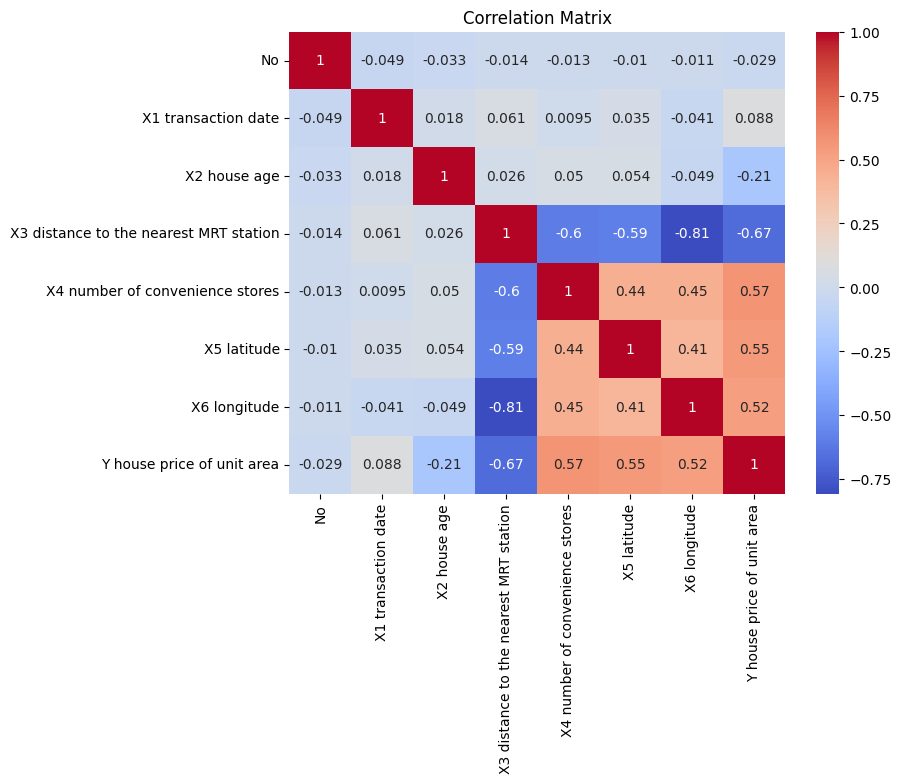

In [5]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [6]:
df = df.drop("No", axis=1)

df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [7]:
X = df.drop(
    "Y house price of unit area",
    axis=1
)

y = df[
    "Y house price of unit area"
]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [9]:
pipeline = Pipeline([

    ('imputer',

     SimpleImputer(
         strategy='median'
     )
    ),

    ('scaler',

     StandardScaler()
    ),

    ('model',

     RandomForestRegressor(
         random_state=42
     )
    )

])

In [10]:
params = {

    'model__n_estimators':

        [100,200,300],

    'model__max_depth':

        [5,10,20,None],

    'model__min_samples_split':

        [2,5,10]

}

In [11]:
grid = GridSearchCV(

    estimator=pipeline,

    param_grid=params,

    cv=5,

    scoring='r2',

    n_jobs=-1

)

grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 20, None],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='r2')

In [12]:
print("Best Parameters:")

print(
    grid.best_params_
)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 300}


In [13]:
best_model = grid.best_estimator_

y_pred = best_model.predict(
    X_test
)

print(

    "R2 Score :",

    r2_score(
        y_test,
        y_pred
    )

)

print(

    "RMSE :",

    np.sqrt(

        mean_squared_error(

            y_test,

            y_pred

        )

    )

)

R2 Score : 0.8161389940307618
RMSE : 5.553780279110391


In [14]:
importance = pd.DataFrame({

    'Feature':

        X.columns,

    'Importance':

        best_model.named_steps['model']
                  .feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

print(importance)

                                  Feature  Importance
2  X3 distance to the nearest MRT station    0.587657
1                            X2 house age    0.172474
4                             X5 latitude    0.115435
5                            X6 longitude    0.067051
0                     X1 transaction date    0.037074
3         X4 number of convenience stores    0.020308


In [15]:
joblib.dump(

    best_model,

    "house_price_model.pkl"

)

print(

    "Model Saved Successfully!"

)

Model Saved Successfully!


In [16]:
sample = pd.DataFrame({

    'X1 transaction date':

        [2013.5],

    'X2 house age':

        [15],

    'X3 distance to the nearest MRT station':

        [300],

    'X4 number of convenience stores':

        [5],

    'X5 latitude':

        [24.97],

    'X6 longitude':

        [121.54]

})

prediction = best_model.predict(

    sample

)

print(

    "Predicted House Price:",

    prediction[0]

)

Predicted House Price: 46.79019747006741


In [17]:
sample = pd.DataFrame({

    'X1 transaction date': [2013.5],

    'X2 house age': [15],

    'X3 distance to the nearest MRT station': [300],

    'X4 number of convenience stores': [5],

    'X5 latitude': [24.97],

    'X6 longitude': [121.54]

})

prediction = best_model.predict(sample)

print("Predicted House Price per Unit Area:")
print(prediction[0])

Predicted House Price per Unit Area:
46.79019747006741


In [18]:
joblib.dump(best_model, "house_price_model.pkl")

['house_price_model.pkl']

In [19]:
import joblib

model = joblib.load("house_price_model.pkl")

prediction = model.predict(sample)

print(prediction[0])

46.79019747006741


In [20]:
sample = pd.DataFrame({

    'X1 transaction date':[2013.2],

    'X2 house age':[10],

    'X3 distance to the nearest MRT station':[150],

    'X4 number of convenience stores':[8],

    'X5 latitude':[24.98],

    'X6 longitude':[121.54]

})

prediction = best_model.predict(sample)

print("Predicted House Price:", prediction[0])

Predicted House Price: 49.11793026585753


In [21]:
print("R2 Score:", r2_score(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8161389940307618
RMSE: 5.553780279110391


In [22]:
date = float(input("Enter Transaction Date: "))
age = float(input("Enter House Age: "))
mrt = float(input("Distance to MRT: "))
stores = int(input("Convenience Stores: "))
lat = float(input("Latitude: "))
lon = float(input("Longitude: "))

sample = pd.DataFrame({

    'X1 transaction date':[date],

    'X2 house age':[age],

    'X3 distance to the nearest MRT station':[mrt],

    'X4 number of convenience stores':[stores],

    'X5 latitude':[lat],

    'X6 longitude':[lon]

})

prediction = best_model.predict(sample)

print(f"\nPredicted House Price per Unit Area: {prediction[0]:.2f}")

Enter Transaction Date: 2002.4
Enter House Age: 18
Distance to MRT: 200
Convenience Stores: 8
Latitude: 24.98
Longitude: 49.69

Predicted House Price per Unit Area: 42.78


In [23]:
import joblib

joblib.dump(best_model, "house_price_model.pkl")

['house_price_model.pkl']

In [24]:
from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>